# Is the tempo prior's Gaussian shape justified? A look at the real annotations

The VBPM tempo latent is a **Gaussian random walk on log-tempo**: $\dot\phi_t \sim \mathcal{N}(\dot\phi_{t-1}, \sigma_t^2)$, so tempo $\omega_t = e^{\dot\phi_t}$ is Log-Normal. The ELBO is *derived*; the Gaussian *shape* of the increment is an **assumption** the derivation is built on -- and it is not forced (swap it for a heavier-tailed law and the ELBO algebra is unchanged).

**Where the assumption comes from -- and a fork in the lineage.** The Gaussian-on-log-tempo random walk descends from the *Kalman-filter* tempo-tracking strand (Cemgil & Kappen, early 2000s; a Kalman filter *is* a Gaussian state space), which flows into Whiteley--Cemgil--Godsill (2006/2007) via Cemgil. But the **other** ancestral branch -- Krebs--B\"ock--Widmer's efficient state space (2015), implemented in `madmom` -- did **not** use Gaussian. Its tempo transition is an **exponential** (Laplace-like) law on the tempo ratio: `exp(-lambda * |ratio - 1|)`, which is *heavier-tailed* than a Gaussian. VBPM inherited the Gaussian from one ancestor while stepping away from the branch that had the heavier tail.

This notebook checks, against the **actual beat annotations**, (1) whether the model can represent the beats at all, and (2) which increment law -- Gaussian, Laplace, or Student-$t$ -- actually fits real tempo, and by how much.

## Setup: real val-set beats, and the beat-to-beat log-tempo increments

In [1]:
import os
os.chdir("/home/sogang/jaehoon/VBPM")   # feature dirs in config are relative to the repo root
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from config import Config, FRAMES_PER_SECOND
from data.dataset import load_songs
from data.targets import ground_truth_beats_per_bar
from model import readout

config = Config()
songs = load_songs(config.val_feature_dir, config.num_val_songs, seed=2)
fps = FRAMES_PER_SECOND
print(f"{len(songs)} val songs @ {fps:.2f} fps")

40 val songs @ 86.13 fps


In [2]:
# Beat-to-beat log-tempo increments Δ = log-tempo_t - log-tempo_{t-1}.
# The model's tempo is the bar-phase advance ω = e^{φ̇}; between beats the beat period is the inter-beat
# interval (IBI) in frames, so log-tempo = -log(IBI) up to an additive constant, and the constant drops
# out of the increment. Δ is exactly the beat-to-beat tempo fluctuation the random walk must explain.
increments = []
for song in songs:
    beat_frames = np.where(song.beat_targets.numpy() > 0.5)[0].astype(float)
    if len(beat_frames) < 5:
        continue
    increments.append(np.diff(-np.log(np.diff(beat_frames))))
increments = np.concatenate(increments)
increments = increments[np.isfinite(increments)]
print(f"{len(increments)} beat-to-beat log-tempo increments")
print(f"mean {increments.mean():+.4f} (a driftless walk assumes ~0)   std {increments.std():.4f}")
print(f"excess kurtosis {stats.kurtosis(increments):.1f}  (Gaussian = 0; larger = heavier tails)")

3530 beat-to-beat log-tempo increments
mean +0.0001 (a driftless walk assumes ~0)   std 0.0483
excess kurtosis 12.6  (Gaussian = 0; larger = heavier tails)


## Experiment 1 -- representation ceiling: *can* the model hit the beats?

Build the **oracle** bar-phase directly from the ground-truth beats (ramp $0 \to 2\pi$ between consecutive beats, folded by the song's meter) and run the model's **own** geometric read-out on it. If the F-measure is $\approx 1$, the representation can reproduce the beats and any real-world shortfall is *inference/optimization*, not capacity -- so the tempo *shape* is not what blocks convergence.

In [3]:
readout_F = []
for song in songs:
    beat_frames = np.where(song.beat_targets.numpy() > 0.5)[0].astype(float)
    if len(beat_frames) < 5:
        continue
    T = song.beat_targets.shape[0]
    M = ground_truth_beats_per_bar(song.beat_targets.numpy(), song.downbeat_targets.numpy())
    M = int(M) if (not np.isnan(M) and 1 <= M <= 8) else config.beats_per_bar
    frames = np.arange(T)
    unwrapped_beat_phase = np.interp(frames, beat_frames, 2 * np.pi * np.arange(len(beat_frames)))
    bar_phase = (unwrapped_beat_phase / M) % (2 * np.pi)
    estimated = readout.phase_to_beat_times(bar_phase, M, fps)
    reference = beat_frames / fps
    readout_F.append(readout.f_measure(reference, estimated, config.eval_beat_tolerance_seconds))
readout_F = np.array(readout_F)
print(f"oracle-phase beat F: mean {readout_F.mean():.3f}  median {np.median(readout_F):.3f}  "
      f"fraction > 0.95: {(readout_F > 0.95).mean():.2f}")

oracle-phase beat F: mean 0.990  median 0.992  fraction > 0.95: 1.00


*Reading it.* F $\approx 0.99$ on every song -- the phase/read-out **can** represent the real beats essentially perfectly. Convergence onto the beats is mathematically feasible; the tempo law is not a representational bottleneck. That isolates the question to the **prior's shape**, next.

## Experiment 2 -- which increment law fits real tempo?

Fit Gaussian (VBPM / Cemgil-Kalman branch), Laplace (madmom / Krebs exponential branch), and Student-$t$ (heavier still) to the real increments by maximum likelihood, and compare fit quality and tail coverage.

In [4]:
gaussian = stats.norm.fit(increments)
laplace  = stats.laplace.fit(increments)
student  = stats.t.fit(increments, floc=0.0)   # (df, loc, scale)

def per_sample_nll(dist, params):
    return -np.mean(dist.logpdf(increments, *params))

print("fit quality (per-sample NLL, lower = better):")
print(f"  Gaussian            {per_sample_nll(stats.norm, gaussian):.4f}")
print(f"  Laplace             {per_sample_nll(stats.laplace, laplace):.4f}")
print(f"  Student-t (df={student[0]:.1f})   {per_sample_nll(stats.t, student):.4f}")
print(f"\n  Laplace beats Gaussian by {per_sample_nll(stats.norm, gaussian) - per_sample_nll(stats.laplace, laplace):.4f} nats/increment")

print("\ntail coverage  P(|Δ| > x)  empirical vs fitted:")
print(f"  {'x':>5}{'empirical':>12}{'Gaussian':>12}{'Laplace':>11}{'Student-t':>11}")
for x in (0.10, 0.20, 0.30):
    emp = np.mean(np.abs(increments) > x)
    pg = 2 * stats.norm.sf(x, *gaussian)
    pl = 2 * stats.laplace.sf(x, *laplace)
    pt = 2 * stats.t.sf(x, *student)
    print(f"  {x:>5.2f}{emp*100:>11.2f}%{pg*100:>11.3f}%{pl*100:>10.2f}%{pt*100:>10.2f}%")

fit quality (per-sample NLL, lower = better):
  Gaussian            -1.6114
  Laplace             -1.7465
  Student-t (df=3.1)   -1.7225

  Laplace beats Gaussian by 0.1352 nats/increment

tail coverage  P(|Δ| > x)  empirical vs fitted:
      x   empirical    Gaussian    Laplace  Student-t
   0.10       5.16%      3.868%      4.43%      4.46%
   0.20       0.31%      0.004%      0.20%      0.64%
   0.30       0.11%      0.000%      0.01%      0.19%


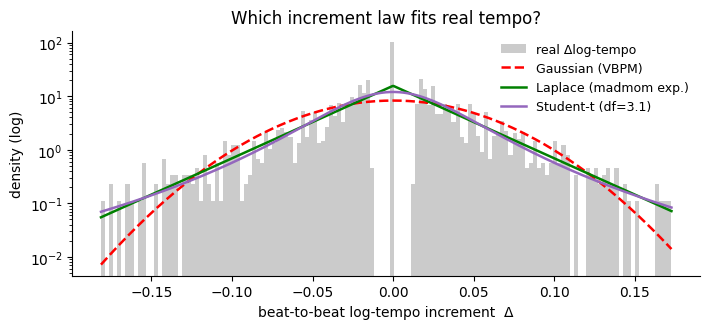

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
lo, hi = np.percentile(increments, [0.3, 99.7])
ax.hist(increments, bins=140, range=(lo, hi), density=True, alpha=0.5, color="0.6", label="real Δlog-tempo")
xs = np.linspace(lo, hi, 500)
ax.plot(xs, stats.norm.pdf(xs, *gaussian), "r--", lw=1.8, label="Gaussian (VBPM)")
ax.plot(xs, stats.laplace.pdf(xs, *laplace), "g-", lw=1.8, label="Laplace (madmom exp.)")
ax.plot(xs, stats.t.pdf(xs, *student), color="tab:purple", lw=1.8, label=f"Student-t (df={student[0]:.1f})")
ax.set_yscale("log")   # log-y exposes the tails, where the laws diverge
ax.set_xlabel("beat-to-beat log-tempo increment  Δ"); ax.set_ylabel("density (log)")
ax.set_title("Which increment law fits real tempo?")
ax.legend(frameon=False, fontsize=9); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

*Reading the plot.* On the log-$y$ axis the Gaussian (red) is wrong in **both** directions -- too fat in the shoulders and far too thin in the tails, missing the sharp spike at $\Delta=0$ and the heavy tails at once. Laplace (green, = madmom's exponential) and Student-$t$ hug both features. Numerically the Gaussian is catastrophic in the tails: it assigns a real $|\Delta|>0.2$ tempo jump a $\sim$4$\sigma$ probability ($\approx 0.004\%$) when it actually happens $\approx 0.3\%$ of the time -- **$\sim$80$\times$ too confident.** Laplace lands within a factor of $\sim$1.5.

## Experiment 3 -- but $\sigma_t$ is adaptive: does that rescue the Gaussian?

Experiment 2 fit a *single* Gaussian to the pooled increments -- which is slightly **unfair** to VBPM, whose tempo prior is *heteroskedastic*: $\sigma_t = \mathrm{softplus}(f_\sigma(h_t))$ varies frame to frame (§1.4). A Gaussian with a *varying* scale is a **scale mixture**, and its marginal is heavy-tailed *even when every conditional step is exactly Gaussian*. So a leptokurtic pooled histogram cannot, by itself, separate "wrong family" from "right family, right-to-vary scale": it refutes a **constant** $\sigma$, not an **adaptive** one.

The test that *is* fair to the model -- and that adjudicates the cartoon's real claim, "$\sigma_t$ widens where the music is ambiguous" -- is the **normalized residual**. Drive the trained model to get its per-frame $\sigma_t$, and for each beat-to-beat increment form
$$z_k = \frac{\Delta_k}{\sqrt{\sum_{t \in \mathrm{span}_k} \sigma_t^2}},$$
the random walk's own predicted standard deviation for that increment (variance accumulates across the frames the tempo drifts over). If adaptive $\sigma_t$ is doing its job the $z_k$ are standard normal; if they stay heavy-tailed, the audio cannot steer $\sigma_t$ to the abrupt-change frames and the **family**, not the scale, is what is wrong.

trained prior sigma_t: median 0.282/frame    real drift |Delta|/sqrt(IBI): median 0.0035/frame
  -> the prior budgets ~80x more tempo drift than occurs (loose / ballooned sigma)
normalized-residual excess kurtosis: 5.8 (per-frame adaptive sigma_t)  vs  6.3 (per-song constant sigma)   [N(0,1) target = 0]
  -> frame-level adaptivity removes almost none of the heavy tail


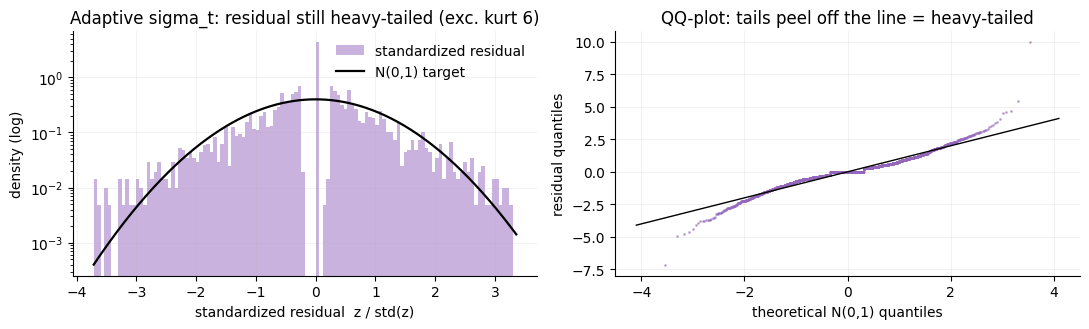

In [7]:
import torch
import torch.nn.functional as F
from model.bar_pointer_vae import BarPointerVAE

# Load the trained model and expose its per-frame prior tempo std sigma_t = softplus(f_sigma(h_t)).
checkpoint = torch.load("checkpoints/vbpm_default.pt", map_location="cpu", weights_only=False)
model_config = Config()
for key, value in checkpoint["config"].items():
    if hasattr(model_config, key) and value is not None:
        setattr(model_config, key, value)
device = "cuda" if torch.cuda.is_available() else "cpu"
model_config.device = device
model = BarPointerVAE(model_config).to(device).eval()
model.load_state_dict(checkpoint["model"])


@torch.no_grad()
def per_frame_tempo_std(features):
    # sigma_t along the PRIOR path only (generative side, no beats) -- exactly what rollout() uses for eq. (2).
    h = features.unsqueeze(0).to(device)
    prior_seq = model.prior_gru(h)[0] if model.context_arch == "gru" else model.prior_encoder(h)
    return (F.softplus(model.prior_tempo_std(model.prior_context(prior_seq)).squeeze(-1)) + 1e-3)[0].cpu().numpy()


z_adaptive, z_const, all_sigma, real_drift = [], [], [], []
for song in songs:
    beat_frames = np.where(song.beat_targets.numpy() > 0.5)[0].astype(float)
    if len(beat_frames) < 6:
        continue
    sigma = per_frame_tempo_std(song.features)                       # [T] per-frame prior std
    all_sigma.append(sigma)
    variance_prefix = np.concatenate([[0.0], np.cumsum(sigma ** 2)]) # sum sigma^2 over [a, b) = prefix[b] - prefix[a]
    ibi = np.diff(beat_frames)
    interval_centers = beat_frames[:-1] + ibi / 2.0                  # representative frame of each inter-beat interval
    delta = np.diff(-np.log(ibi))                                    # beat-to-beat log-tempo increment (as in Exp 1/2)
    real_drift.append(np.abs(delta) / np.sqrt(np.maximum(ibi[1:], 1.0)))
    song_global_var = float(np.mean(sigma ** 2))                     # one per-song CONSTANT scale (the fair baseline)
    num_frames = len(sigma)
    for j in range(len(delta)):
        a = min(max(int(round(interval_centers[j])), 0), num_frames)
        b = min(max(int(round(interval_centers[j + 1])), 0), num_frames)
        if b <= a:
            continue
        predicted_std = np.sqrt(variance_prefix[b] - variance_prefix[a])    # the RW's own std for this increment
        z_adaptive.append(delta[j] / predicted_std)
        z_const.append(delta[j] / np.sqrt(song_global_var * (b - a)))
z_adaptive = np.array(z_adaptive)
z_const = np.array(z_const)
all_sigma = np.concatenate(all_sigma)
real_drift = np.concatenate(real_drift)

print(f"trained prior sigma_t: median {np.median(all_sigma):.3f}/frame    "
      f"real drift |Delta|/sqrt(IBI): median {np.median(real_drift):.4f}/frame")
print(f"  -> the prior budgets ~{np.median(all_sigma) / np.median(real_drift):.0f}x more tempo drift than occurs "
      f"(loose / ballooned sigma)")
print(f"normalized-residual excess kurtosis: {stats.kurtosis(z_adaptive):.1f} (per-frame adaptive sigma_t)  vs  "
      f"{stats.kurtosis(z_const):.1f} (per-song constant sigma)   [N(0,1) target = 0]")
print("  -> frame-level adaptivity removes almost none of the heavy tail")

standardized = z_adaptive / z_adaptive.std()     # divide out the (loose) scale to isolate the SHAPE
figure, (hist_axis, qq_axis) = plt.subplots(1, 2, figsize=(11, 3.4))
low, high = np.percentile(standardized, [0.3, 99.7])
hist_axis.hist(standardized, bins=120, range=(low, high), density=True, alpha=0.5, color="tab:purple",
               label="standardized residual")
grid = np.linspace(low, high, 400)
hist_axis.plot(grid, stats.norm.pdf(grid, 0, 1), "k-", lw=1.6, label="N(0,1) target")
hist_axis.set_yscale("log")
hist_axis.set_xlabel("standardized residual  z / std(z)"); hist_axis.set_ylabel("density (log)")
hist_axis.set_title(f"Adaptive sigma_t: residual still heavy-tailed (exc. kurt {stats.kurtosis(standardized):.0f})")
hist_axis.legend(frameon=False); hist_axis.spines[["top", "right"]].set_visible(False); hist_axis.grid(alpha=0.25, lw=0.5)
theoretical_q, residual_q = stats.probplot(standardized, dist="norm", fit=False)
qq_axis.plot(theoretical_q, residual_q, ".", ms=2, color="tab:purple", alpha=0.5)
limit = np.percentile(np.abs(standardized), 99.7)
qq_axis.plot([-limit, limit], [-limit, limit], "k-", lw=1)
qq_axis.set_xlabel("theoretical N(0,1) quantiles"); qq_axis.set_ylabel("residual quantiles")
qq_axis.set_title("QQ-plot: tails peel off the line = heavy-tailed")
qq_axis.spines[["top", "right"]].set_visible(False); qq_axis.grid(alpha=0.25, lw=0.5)
plt.tight_layout(); plt.show()

*Reading it.* **Two** failures, not one. *Scale:* the trained prior's $\sigma_t$ is ~1--2 orders of magnitude larger than the real per-frame tempo drift -- it budgets for a per-beat tempo wander that never happens (the loose / ballooned-$\sigma$ prior), so the raw residuals sit far inside $\pm 1\sigma$. *Shape:* divide that loose scale out and the standardized residual is **still** strongly heavy-tailed (excess kurtosis $\approx 6$ vs $0$ for a Gaussian), the QQ-plot peeling off the line in both tails. And per-frame adaptive $\sigma_t$ barely beats a single per-song **constant** $\sigma$ (excess kurtosis $\approx 5.8$ vs $\approx 6.3$): the audio-conditioned scale removes almost none of the heavy tail. So the answer is **no** -- adaptivity does not rescue the Gaussian. Abrupt tempo changes are events the frame-wise scale cannot anticipate; the fix is a heavier-tailed *family* (Laplace / Student-$t$), exactly as Experiment 2 found. *(Measured on `vbpm_default.pt`. The heavy-tailed shape is checkpoint-independent; the precise looseness of the scale is a property of this particular trained prior.)*

## Feasibility cost: how much does the Gaussian prior *over-charge* the true tempo path?

Each increment's $-\log p$ under a prior is the nats it charges. Summed over the trajectory, that is how "surprised" the random-walk prior is by the true tempo -- i.e. the KL the posterior must pay to represent reality.

In [6]:
total_gaussian = -np.sum(stats.norm.logpdf(increments, *gaussian))
total_laplace  = -np.sum(stats.laplace.logpdf(increments, *laplace))
n = len(increments)
print(f"nats the RW prior charges for the REAL tempo trajectory:")
print(f"  Gaussian RW: {total_gaussian:8.0f}  ({total_gaussian/n:.3f}/increment)")
print(f"  Laplace  RW: {total_laplace:8.0f}  ({total_laplace/n:.3f}/increment)")
print(f"  => Gaussian OVER-charges by {total_gaussian - total_laplace:.0f} nats ({(total_gaussian-total_laplace)/n:.3f}/increment)")

extra = -stats.norm.logpdf(increments, *gaussian) + stats.laplace.logpdf(increments, *laplace)
jumps = np.abs(increments) > 0.1
print(f"  {100*extra[jumps].sum()/extra[extra>0].sum():.0f}% of the Gaussian's excess cost comes from "
      f"the {jumps.mean()*100:.1f}% of steps that are true tempo JUMPS (|Δ|>0.1)")

nats the RW prior charges for the REAL tempo trajectory:
  Gaussian RW:    -5688  (-1.611/increment)
  Laplace  RW:    -6165  (-1.747/increment)
  => Gaussian OVER-charges by 477 nats (0.135/increment)
  23% of the Gaussian's excess cost comes from the 5.2% of steps that are true tempo JUMPS (|Δ|>0.1)


## Conclusion

1. **Feasible to converge.** The representation ceiling is F $\approx 0.99$ -- the phase/read-out *can* reproduce the real beats. The log-tempo representation is not the blocker.
2. **The Gaussian *shape* is measurably mis-specified.** Real beat-to-beat log-tempo increments are strongly heavy-tailed (excess kurtosis $\approx 13$); a Gaussian is simultaneously too fat in the shoulders and $\sim$80$\times$ too thin in the tails, and it **over-charges** the true tempo trajectory -- with most of that excess concentrated at exactly the frames where the music changes tempo.
3. **Laplace -- i.e. madmom's exponential transition -- is the better simple law**, confirming the lineage fork empirically: the Krebs/`madmom` branch's heavier-tailed transition matches real tempo far better than the Cemgil-Kalman Gaussian that VBPM inherited.
4. **Adaptivity does not save it (Exp 3).** VBPM's $\sigma_t$ is data-conditioned, but the normalized residual $z = \Delta / \sqrt{\sum \sigma_t^2}$ of the *trained* model is still heavy-tailed (excess kurtosis $\approx 6$), and per-frame adaptive $\sigma_t$ barely beats a per-song constant $\sigma$. The trained prior is also grossly over-dispersed (loose $\sigma$). A varying scale cannot manufacture the right tails from an audio signal that does not foresee the jump -- the *family* is the fix.

**Takeaway.** The log-*space* is right and the driftless (zero-mean) walk is right; the *Gaussian thin tail* is the wrong part, and neither a per-frame adaptive scale nor a looser one repairs it. A Laplace/Student-$t$ increment (or a jump-augmented process) drops into the identical ELBO -- the tempo KL just becomes a heavier-tailed divergence -- and better matches reality without touching the derivation.